# **1️⃣ Imports & Setup**

In [1]:
import os
import cv2
import numpy as np
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications import MobileNetV2

2026-03-30 21:04:05.054200: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774904645.238719      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774904645.294373      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774904645.718612      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774904645.718648      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774904645.718651      55 computation_placer.cc:177] computation placer alr

# **2️⃣ Constants & Dataset Paths**

In [2]:
# Constants to prevent OOM errors
TARGET_FRAMES = 32
IMG_SIZE = (128, 128)
BATCH_SIZE = 1
DATASET_PATH = "/kaggle/input/datasets/mahmoudosamahassan/shop-dataset/Shop DataSet/"

# **3️⃣ Load Dataset Files**

In [3]:
non_shop_path = os.path.join(DATASET_PATH, "non shop lifters")
shop_path = os.path.join(DATASET_PATH, "shop lifters")

non_shop_files = [os.path.join(non_shop_path, f) for f in os.listdir(non_shop_path) if f.endswith('.mp4')]
shop_files = [os.path.join(shop_path, f) for f in os.listdir(shop_path) if f.endswith('.mp4')]

print(f"Total Non-Shoplifting videos: {len(non_shop_files)}")
print(f"Total Shoplifting videos: {len(shop_files)}")

Total Non-Shoplifting videos: 531
Total Shoplifting videos: 324


# **4️⃣ Remove Duplicate Videos**

In [4]:
def get_file_hash(file_path):
    hasher = hashlib.md5()
    try:
        with open(file_path, 'rb') as f:
            for chunk in iter(lambda: f.read(4096), b""):
                hasher.update(chunk)
        return hasher.hexdigest()
    except: return None

def remove_duplicates(file_list):
    unique_files, seen_hashes = [], set()
    for f in file_list:
        if os.path.exists(f):
            h = get_file_hash(f)
            if h and h not in seen_hashes:
                seen_hashes.add(h)
                unique_files.append(f)
    return unique_files

In [5]:
# Clean both categories
unique_non_shop = remove_duplicates(non_shop_files)
unique_shop = remove_duplicates(shop_files)

# **5️⃣ Train / Validation Split**

In [6]:
# Split unique files
train_non, val_non = train_test_split(unique_non_shop, test_size=0.2, random_state=42)
train_shop, val_shop = train_test_split(unique_shop, test_size=0.2, random_state=42)

# **6️⃣ Video Processing & Data Generator**

In [7]:
def load_and_sample_video(video_path, target_frames=TARGET_FRAMES, size=IMG_SIZE):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, size)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame / 255.0)
    cap.release()

    if len(frames) == 0:
        return np.zeros((target_frames, size[0], size[1], 3))

    indices = np.linspace(0, len(frames) - 1, target_frames).astype(int)
    sampled_frames = [frames[i] for i in indices]
    return np.array(sampled_frames)

def data_generator(non_shop_files, shop_files, batch_size=BATCH_SIZE):
    all_files = [(f, 0) for f in non_shop_files] + [(f, 1) for f in shop_files]
    while True:
        np.random.shuffle(all_files)
        for i in range(0, len(all_files), batch_size):
            batch_data = all_files[i : i + batch_size]
            X_batch, Y_batch = [], []
            for file_path, label in batch_data:
                frames = load_and_sample_video(file_path)
                X_batch.append(frames)
                Y_batch.append(label)
            yield np.array(X_batch), np.array(Y_batch)

# **7️⃣ Model: Pre-trained (MobileNetV2)**

**Feature Extractor (Backbone)**

In [8]:
# 1. Load Pretrained Backbone (MobileNetV2 is fast and efficient for video)
# We set include_top=False to remove the 1000-class ImageNet classifier
video_backbone = MobileNetV2(
    input_shape=(128, 128, 3), 
    include_top=False, 
    weights='imagenet',
    pooling='avg' # Global Average Pooling to flatten spatial dimensions into a vector
)

# 2. Freeze the backbone so we don't destroy pretrained patterns during early training
video_backbone.trainable = False

I0000 00:00:1774904684.566776      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


**Full Architecture**

In [9]:
# 3. Define the Time-Series Model
model = models.Sequential([
    # Input: (None, 32, 128, 128, 3)
    layers.Input(shape=(TARGET_FRAMES, 128, 128, 3)),
    
    # Apply the pretrained backbone to every frame independently
    layers.TimeDistributed(video_backbone),
    
    # LSTM to analyze the sequence of extracted features
    layers.LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    
    # Dense Classifier
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

**Compile model**

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 32, 1280)       │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,987,713 (11.40 MB)

 Trainable params: 729,729 (2.78 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **8️⃣ Training Setup**

In [11]:
# 1. Prepare Generators
# Prepare your generators with the split lists
train_gen = data_generator(train_non, train_shop, batch_size=BATCH_SIZE)
val_gen = data_generator(val_non, val_shop, batch_size=BATCH_SIZE)

# 2. Calculate steps
train_steps = (len(train_non) + len(train_shop)) // BATCH_SIZE
val_steps = (len(val_non) + len(val_shop)) // BATCH_SIZE

# 3. Calculate how many batches make one full cycle
total_videos = len(non_shop_files) + len(shop_files)
steps_per_epoch = total_videos // BATCH_SIZE

# 4. Set up the Early Stopping "Safety Net"
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=5,          # Stops if the model doesn't improve for 5 straight epochs
    restore_best_weights=True
)

# **9️⃣ Training**

In [12]:
# Execute Training
print(f"Training started for {total_videos} videos...")
history = model.fit(
    train_gen,
    steps_per_epoch=train_steps,
    validation_data=val_gen,
    validation_steps=val_steps,
    epochs=10,
    callbacks=[early_stop]
)

Training started for 855 videos...
Epoch 1/10


I0000 00:00:1774904801.141520     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


509/509 ━━━━━━━━━━━━━━━━━━━━ 356s 477ms/step - accuracy: 0.5320 - loss: 0.6843 - val_accuracy: 0.8984 - val_loss: 0.5306
Epoch 2/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 202s 396ms/step - accuracy: 0.7629 - loss: 0.5310 - val_accuracy: 0.9141 - val_loss: 0.3890
Epoch 3/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 206s 406ms/step - accuracy: 0.8270 - loss: 0.4110 - val_accuracy: 0.9531 - val_loss: 0.2273
Epoch 4/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 206s 406ms/step - accuracy: 0.8574 - loss: 0.3598 - val_accuracy: 0.8672 - val_loss: 0.2954
Epoch 5/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 210s 413ms/step - accuracy: 0.8353 - loss: 0.3269 - val_accuracy: 0.9531 - val_loss: 0.1551
Epoch 6/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 205s 404ms/step - accuracy: 0.9016 - loss: 0.2550 - val_accuracy: 0.9531 - val_loss: 0.1762
Epoch 7/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 207s 406ms/step - accuracy: 0.9174 - loss: 0.1991 - val_accuracy: 0.9609 - val_loss: 0.1118
Epoch 8/10
509/509 ━━━━━━━━━━━━━━━━━━━━ 187s 368ms/step - accuracy: 0.9286 - loss: 0.18

# **🔟 Plot Training Results & Evalutaion**

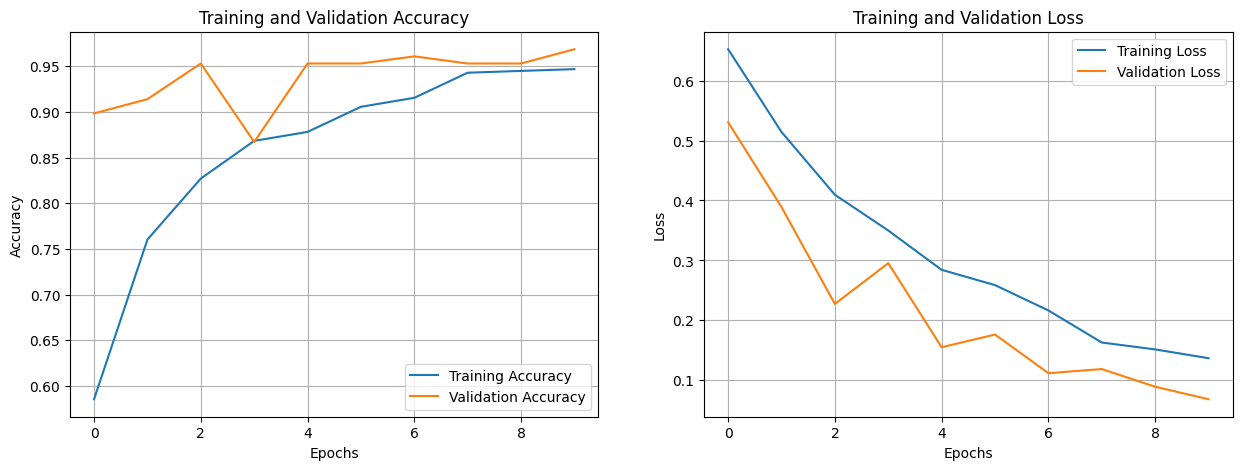

In [13]:
def plot_training_results(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.show()

# Call the function with your history object
plot_training_results(history)

In [14]:
# 1. Reset validation generator to start from the beginning
val_gen = data_generator(val_non, val_shop, batch_size=BATCH_SIZE)

all_labels = []
all_preds = []

print("Evaluating validation set...")
# Loop through the validation steps to get all predictions
for i in range(val_steps):
    x_batch, y_batch = next(val_gen)
    preds = model.predict(x_batch, verbose=0)
    
    all_labels.extend(y_batch)
    all_preds.extend((preds > 0.5).astype(int).flatten())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

Evaluating validation set...


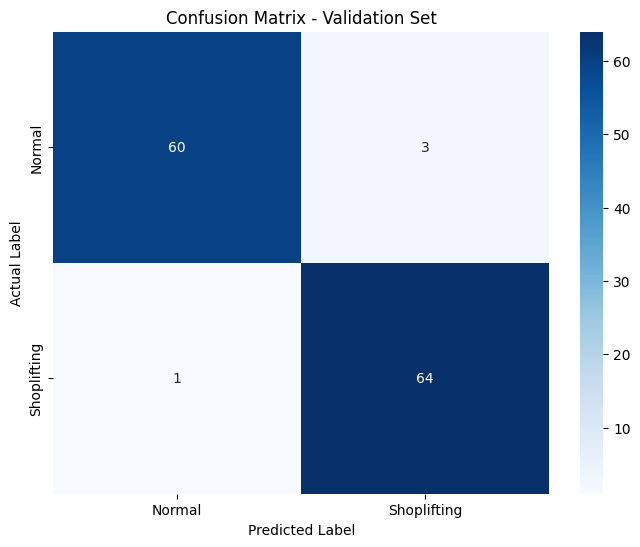

In [15]:
# 2. Generate and Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Shoplifting'], 
            yticklabels=['Normal', 'Shoplifting'])
plt.title('Confusion Matrix - Validation Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [16]:
# 3. Print F1-Score and Classification Report
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Shoplifting']))


--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.98      0.95      0.97        63
 Shoplifting       0.96      0.98      0.97        65

    accuracy                           0.97       128
   macro avg       0.97      0.97      0.97       128
weighted avg       0.97      0.97      0.97       128



In [17]:
# Save the model in the standard Keras format
model.save('video_pretrained.keras')
print("Model saved successfullyy!")

Model saved successfullyyy!


In [18]:
# Save weights only (version-independent)
model.save_weights('video_pretrained.weights.h5')
print("Weights saveddd!")

Weights saveddd!


In [19]:
import zipfile

zip_path = '/kaggle/working/model.zip'
file_path = '/kaggle/working/video_pretrained.weights.h5'

with zipfile.ZipFile(zip_path, 'w') as zipf:
    zipf.write(file_path, arcname='video_pretrained.weights.h5')